In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
from faker import Faker
import random
faker=Faker()
data=[]
resturant=["Dominos", "KFC", "Burger King", "Pizza Hut", "Subway"]
for _ in range(300):
    data.append({
        "order_id":faker.uuid4(),
        "resturant":random.choice(resturant),
        "order_value":random.randint(100,1000),
        "delivery_time":random.randint(10,20),
        "customer_rating":round(random.uniform(3.5,4.5),2)
    })
    df=pd.DataFrame(data)
    df.to_csv("Food_Delivery.csv")
   

In [18]:
df.head()

,order_id,resturant,order_value,delivery_time,customer_rating
0,6879df88-cddc-46fd-921e-fe765a6cd09e,Dominos,444,12,3.73
1,f24ab71b-58b8-4ae6-9881-3712ac01cc9c,KFC,272,19,3.64
2,2b50f022-f836-4ab9-a13a-d915bb27fcd0,Subway,433,11,3.84
3,f68904a2-7e4e-44e2-8e7f-1c7fc303604e,Burger King,794,19,4.16
4,742bdbba-ef1b-46e4-909d-866f7b69a5dd,Burger King,272,10,3.78


In [19]:
restaurant_avg = df.groupby('resturant')['customer_rating'].mean()
overall_avg = df['customer_rating'].mean()
poor_restaurants = restaurant_avg[restaurant_avg < overall_avg]

print("Poorly Performing Restaurants:")
print(poor_restaurants)


Poorly Performing Restaurants:
resturant
Burger King    3.973860
Dominos        3.964306
Subway         3.987857
Name: customer_rating, dtype: float64


In [20]:
final_amount=df.groupby('resturant')['order_value'].sum()
final_amount

resturant
Burger King    32195
Dominos        43344
KFC            34954
Pizza Hut      29451
Subway         32486
Name: order_value, dtype: int64

In [23]:
delivery_time=np.percentile(df['delivery_time'],[25,50,75,90,95])
print(delivery_time[0])
print(delivery_time[1])
print(delivery_time[2])
print(delivery_time[3])
print(delivery_time[4])

12.0
14.0
18.0
19.0
20.0


In [24]:
df['delivery_time'].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
295    False
296    False
297    False
298    False
299    False
Name: delivery_time, Length: 300, dtype: bool

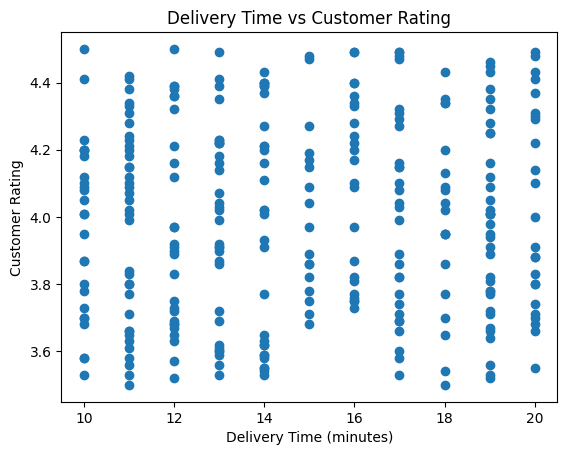

In [25]:
plt.figure()
plt.scatter(df['delivery_time'], df['customer_rating'])
plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Customer Rating")
plt.show()

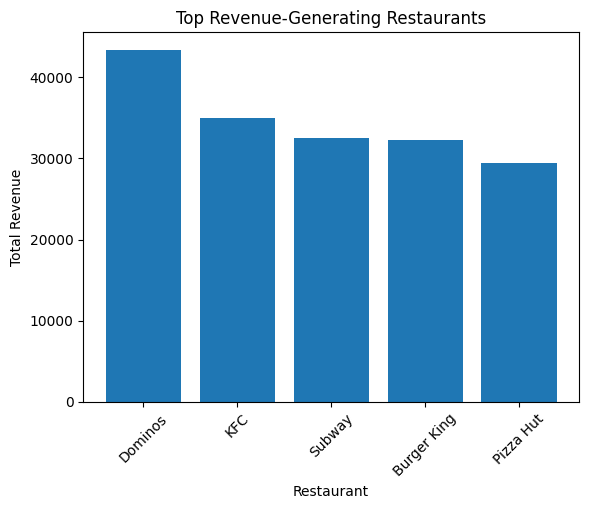

In [27]:
revenue = df.groupby('resturant')['order_value'].sum()
top_restaurants = revenue.sort_values(ascending=False).head(5)
plt.figure()
plt.bar(top_restaurants.index, top_restaurants.values)
plt.title("Top Revenue-Generating Restaurants")
plt.xlabel("Restaurant")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()